In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

%matplotlib inline

X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

X

array([[10.31499195, -5.31182204],
       [ 2.25673296,  3.39655162],
       [ 1.90814691, -9.99600285],
       ...,
       [ 1.39534177,  2.41306789],
       [ 2.68098879, -9.45159003],
       [ 4.58499767, -8.79794437]])

In [2]:
y

array([0, 2, 1, 1, 2, 2, 1, 0, 1, 1, 0, 1, 1, 0, 2, 0, 0, 2, 1, 2, 1, 1,
       1, 2, 1, 2, 0, 0, 1, 2, 2, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 2, 1, 2, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 1, 1,
       0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 2, 1, 1, 2, 1, 2, 0, 0, 0, 1,
       2, 2, 0, 2, 0, 2, 2, 1, 2, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 1,
       0, 1, 0, 2, 0, 0, 0, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 2, 2, 1, 0, 2, 0, 2, 0, 1, 0, 0, 2, 1, 1, 0, 1, 1, 2, 0, 2, 1,
       1, 2, 0, 1, 2, 2, 1, 0, 2, 0, 2, 0, 2, 2, 2, 1, 2, 0, 1, 0, 0, 2,
       2, 1, 1, 0, 1, 0, 2, 0, 2, 0, 1, 2, 2, 2, 0, 0, 1, 2, 0, 0, 1, 1,
       0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 1, 2, 2, 2, 2, 1, 0, 2, 2, 1, 1,
       0, 1, 2, 0, 2, 2, 1, 2, 1, 0, 1, 1, 1, 2, 2, 0, 1, 0, 1, 1, 2, 2,
       0, 1, 2, 2, 1, 1, 1, 1, 2, 0, 1, 0, 2, 0, 2, 1, 0, 1, 0, 1, 0, 0,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 0, 1, 0, 2, 0, 2, 1, 1, 1, 1, 2, 0,
       1, 0, 2, 0, 2, 0, 0, 0, 1, 1, 2, 1, 2, 1, 0,

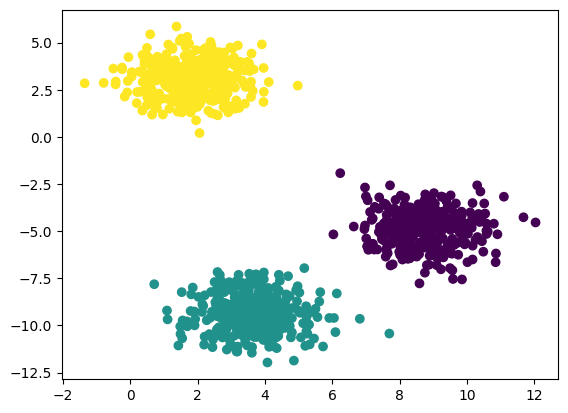

In [3]:
plt.scatter(X[:, 0], X[:, 1],c=y)

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.cluster import KMeans

# Elbow method to select K value
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

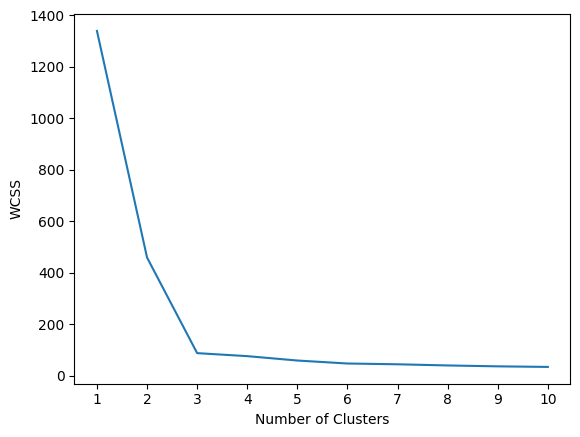

In [6]:
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, init="k-means++")

kmeans.fit_predict(X_train_scaled)

array([0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       2, 1, 1, 1, 1, 0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 0, 1, 2, 2, 1, 1, 1,
       2, 2, 0, 0, 1, 0, 2, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 0,
       2, 0, 0, 0, 2, 0, 2, 0, 1, 0, 1, 2, 0, 2, 1, 1, 0, 1, 1, 2, 0, 0,
       0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 2, 1, 0, 1, 2, 0, 2, 1, 2,
       1, 2, 1, 1, 2, 2, 0, 0, 2, 0, 0, 2, 1, 1, 2, 0, 0, 0, 1, 1, 1, 0,
       2, 2, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 2, 0, 2, 0, 1, 0, 1, 0, 2, 0,
       1, 2, 1, 0, 0, 0, 0, 0, 1, 1, 2, 2, 0, 0, 2, 0, 1, 2, 0, 1, 2, 2,
       1, 2, 1, 1, 2, 1, 1, 1, 0, 1, 0, 1, 2, 2, 1, 2, 0, 2, 1, 0, 2, 1,
       2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2, 2, 2, 1,
       1, 1, 1, 0, 0, 2, 2, 0, 2, 0, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 2, 0,
       0, 2, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1,
       0, 2, 1, 0, 1, 2, 0, 2, 1, 1, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 2,
       0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 0, 2, 1, 1, 0,

In [8]:
y_pred = kmeans.predict(X_test_scaled)

In [9]:
y_pred = kmeans.predict(X_test_scaled)

In [10]:
y_pred

array([2, 2, 1, 2, 2, 1, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 1, 1, 0, 2, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 2,
       2, 0, 2, 2, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 2, 2, 0, 2, 1, 2, 2, 0,
       0, 0, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       0, 1, 0, 0, 0, 2, 2, 1, 2, 0, 0, 2, 2, 1, 2, 0, 1, 0, 1, 1, 0, 2,
       0, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 2, 1,
       0, 2, 1, 0, 2, 1, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 1, 1,
       0, 2, 0, 1, 0, 2, 1, 2, 0, 0, 2, 2, 0, 1, 1, 0, 1, 1, 1, 2, 2, 0,
       0, 2, 0, 1, 2, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 1,
       2, 0, 0, 2, 2, 1, 2, 0, 1, 0, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 1, 2,
       0, 1, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 0, 2, 1, 1, 2, 1, 2, 2, 2, 0,
       2, 0, 0, 2, 0, 2, 1, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 1, 0, 1, 2,
       2, 1, 1, 1, 2, 2, 1, 2, 1, 0, 1, 2, 2, 1, 0, 2, 2, 1, 2, 0, 0, 2,
       0, 1, 0, 1, 0, 0, 0, 0, 2, 2, 2, 0, 1, 0, 1,

ValueError: 'c' argument has 1000 elements, which is inconsistent with 'x' and 'y' with size 330.

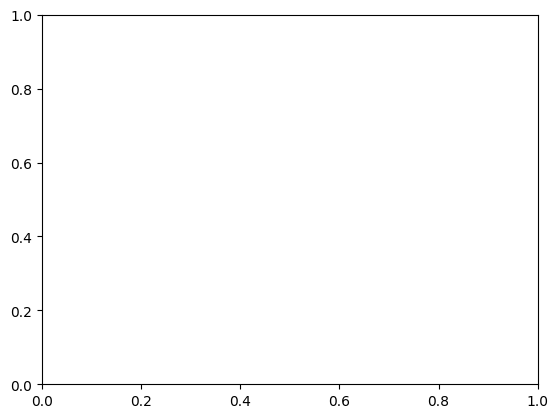

In [11]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y)

In [12]:
kmeans = KMeans(n_clusters=3, init="k-means++")

kmeans.fit_predict(X_train_scaled)

array([1, 1, 2, 2, 2, 0, 1, 1, 2, 2, 0, 1, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       0, 2, 2, 2, 2, 1, 0, 1, 1, 2, 0, 2, 1, 0, 2, 1, 2, 0, 0, 2, 2, 2,
       0, 0, 1, 1, 2, 1, 0, 0, 1, 1, 2, 1, 1, 2, 2, 2, 2, 0, 0, 2, 2, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 2, 1, 2, 0, 1, 0, 2, 2, 1, 2, 2, 0, 1, 1,
       1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1, 2, 0, 2, 1, 2, 0, 1, 0, 2, 0,
       2, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 1,
       0, 0, 0, 2, 2, 2, 1, 2, 2, 2, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 0, 1,
       2, 0, 2, 1, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 1, 2, 0, 1, 2, 0, 0,
       2, 0, 2, 2, 0, 2, 2, 2, 1, 2, 1, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 2,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 2, 2, 1, 1, 0, 0, 0, 1, 2, 0, 0, 0, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 0, 1, 2, 0, 1, 2, 2, 1, 2, 2, 0, 1, 0, 1,
       1, 0, 0, 0, 2, 0, 2, 0, 2, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 1, 2, 2,
       1, 0, 2, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 2, 1, 1, 0, 0, 0, 1, 2, 0,
       1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 1, 0, 2, 2, 1,